In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- MODELOS DE CLASSIFICAÇÃO ("Classifiers") ---
from sklearn.linear_model import LogisticRegression # Diferente do LinearRegression!
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.neural_network import MLPClassifier

# --- MÉTRICAS DE AVALIAÇÃO ---
from sklearn.metrics import accuracy_score, classification_report

# 1. LOAD DATA ("Carregar Dados")
try:
    df = pd.read_parquet('UNSW_NB15_training-set.parquet', engine='fastparquet') # df é apelido padrão para DataFrame ("Tabela de dados")
    print("Dataset loaded successfully! / Base de dados carregada com sucesso!")

    # Visualizar as 5 primeiras linhas para entender o formato dos dados
    display(df.head())

    # Ver o resumo das colunas e tipos de dados
    df.info()



except Exception as e:
    
    print(f"Ocorreu um Erro: {e}.")

Dataset loaded successfully! / Base de dados carregada com sucesso!


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null  float32 


In [2]:
# 1. Separando as respostas (y)
y = df['label']

# 2. Escondendo o gabarito (removendo label e attack_cat das pistas)
X = df.drop(['label', 'attack_cat'], axis=1)

# 3. Traduzindo os textos para números (Transforma colunas como 'proto_tcp' em 0 ou 1)
X = pd.get_dummies(X)

# 4. Dividindo em dados de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Padronizando a escala (deixando todos os números na mesma proporção)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados limpos, traduzidos e padronizados com sucesso!")
print(f"A IA agora vai treinar estudando {X_train_scaled.shape[0]} exemplos com {X_train_scaled.shape[1]} características cada!")

Dados limpos, traduzidos e padronizados com sucesso!
A IA agora vai treinar estudando 140272 exemplos com 186 características cada!


In [3]:
import time

print("Iniciando o treinamento do Random Forest... (pode ir pegar um café ☕)")
tempo_inicio = time.time()

# 1. Escolhendo o modelo (n_jobs=-1 usa todo o poder do seu PC)
modelo_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Treinando o modelo com os 140 mil exemplos
modelo_rf.fit(X_train_scaled, y_train)

tempo_fim = time.time()
print(f"✅ Treinamento concluído em {tempo_fim - tempo_inicio:.3f} segundos!\n")

# 3. Fazendo a prova com os 20% que separamos para teste
print("Avaliando o modelo...")
previsoes_rf = modelo_rf.predict(X_test_scaled)

# 4. Resultados finais!
acuracia = accuracy_score(y_test, previsoes_rf)
print(f"🎯 Acurácia do modelo no mundo real: {acuracia * 100:.3f}%\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, previsoes_rf))

Iniciando o treinamento do Random Forest... (pode ir pegar um café ☕)
✅ Treinamento concluído em 5.792 segundos!

Avaliando o modelo...
🎯 Acurácia do modelo no mundo real: 95.058%

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     11169
           1       0.95      0.98      0.96     23900

    accuracy                           0.95     35069
   macro avg       0.95      0.94      0.94     35069
weighted avg       0.95      0.95      0.95     35069



C:\Users\Rafael Guimarães\AppData\Local\Temp\ipykernel_16896\2704863094.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Importância_Percentual', y='Nome_Explicativo', data=df_importancia, palette='viridis')


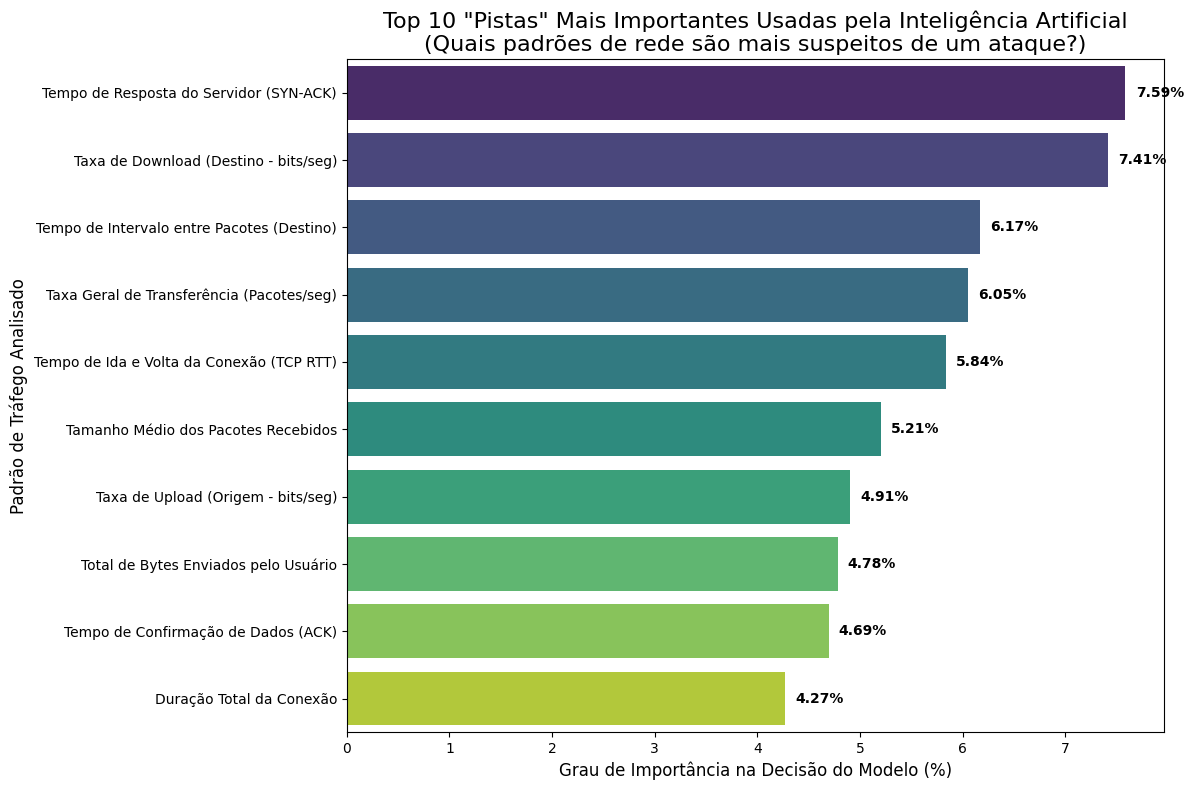

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Extrair os nomes e pontuações
feature_names = X.columns 
importances = modelo_rf.feature_importances_

# 2. Criar o DataFrame, pegar os 10 mais importantes e TRANSFORMAR EM PORCENTAGEM
df_importancia = pd.DataFrame({'Característica': feature_names, 'Importância': importances})
df_importancia = df_importancia.sort_values(by='Importância', ascending=False).head(10)

# Multiplicando por 100 para virar porcentagem real
df_importancia['Importância_Percentual'] = df_importancia['Importância'] * 100

# O dicionário de tradução que fizemos antes
dicionario_traducoes = {
    'synack': 'Tempo de Resposta do Servidor (SYN-ACK)',
    'dload': 'Taxa de Download (Destino - bits/seg)',
    'dinpkt': 'Tempo de Intervalo entre Pacotes (Destino)',
    'rate': 'Taxa Geral de Transferência (Pacotes/seg)',
    'tcprtt': 'Tempo de Ida e Volta da Conexão (TCP RTT)',
    'dmean': 'Tamanho Médio dos Pacotes Recebidos',
    'sload': 'Taxa de Upload (Origem - bits/seg)',
    'sbytes': 'Total de Bytes Enviados pelo Usuário',
    'ackdat': 'Tempo de Confirmação de Dados (ACK)',
    'dur': 'Duração Total da Conexão'
}

# Aplicar a tradução
df_importancia['Nome_Explicativo'] = df_importancia['Característica'].map(dicionario_traducoes).fillna(df_importancia['Característica'])

# 3. Criar o gráfico visual
plt.figure(figsize=(12, 8))
# Note que agora estamos usando a coluna 'Importância_Percentual'
barplot = sns.barplot(x='Importância_Percentual', y='Nome_Explicativo', data=df_importancia, palette='viridis')

# 4. Adicionar títulos atualizados
plt.title('Top 10 "Pistas" Mais Importantes Usadas pela Inteligência Artificial\n(Quais padrões de rede são mais suspeitos de um ataque?)', fontsize=16)
plt.xlabel('Grau de Importância na Decisão do Modelo (%)', fontsize=12)
plt.ylabel('Padrão de Tráfego Analisado', fontsize=12)

# Adicionar os valores exatos formatados com o símbolo %
for p in barplot.patches:
    width = p.get_width()
    plt.text(width + 0.1,  # Um pequeno espaçamento
             p.get_y() + p.get_height() / 2, 
             f'{width:.2f}%', # Formatando para 2 casas decimais e o sinal de %
             ha='left', 
             va='center',
             fontweight='bold')

plt.tight_layout()
plt.show()

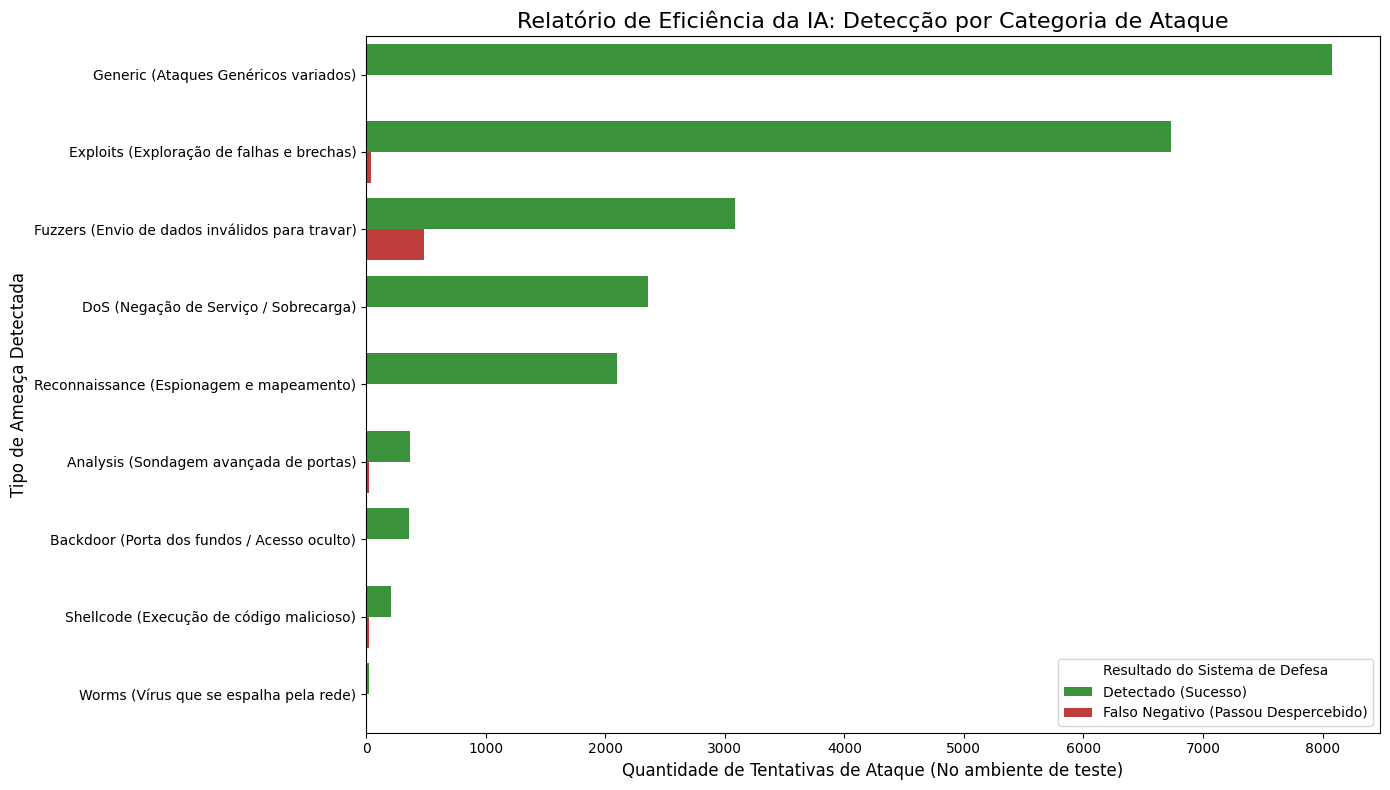


🛡️ RESUMO DO RELATÓRIO DE INCIDENTES (DADOS DE TESTE) 🛡️
Total de ataques reais no teste: 23900
Ataques barrados com sucesso pela IA: 23317 (97.6%)
Ataques que conseguiram enganar a IA: 583 (2.4%)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- RECUPERANDO DADOS PARA O RELATÓRIO ---

indices_teste = X_test.index
df_resultados_teste = df.loc[indices_teste].copy()

# Colocar o que a IA previu ao lado do que realmente era
df_resultados_teste['IA_Previu_Ataque'] = previsoes_rf 

# Filtrar para ver APENAS as linhas que eram ataques reais
df_so_ataques_reais = df_resultados_teste[df_resultados_teste['label'] == 1].copy()

# Criar uma coluna legível de Acerto/Erro
df_so_ataques_reais['Status_Deteccao'] = np.where(df_so_ataques_reais['IA_Previu_Ataque'] == 1,
                                                   'Detectado (Sucesso)',
                                                   'Falso Negativo (Passou Despercebido)')

# --- A MÁGICA: NOME TÉCNICO + EXPLICAÇÃO EM PARÊNTESES ---
traducao_ataques = {
    'Generic': 'Generic (Ataques Genéricos variados)',
    'Exploits': 'Exploits (Exploração de falhas e brechas)',
    'Fuzzers': 'Fuzzers (Envio de dados inválidos para travar)',
    'DoS': 'DoS (Negação de Serviço / Sobrecarga)',
    'Reconnaissance': 'Reconnaissance (Espionagem e mapeamento)',
    'Analysis': 'Analysis (Sondagem avançada de portas)',
    'Backdoor': 'Backdoor (Porta dos fundos / Acesso oculto)',
    'Shellcode': 'Shellcode (Execução de código malicioso)',
    'Worms': 'Worms (Vírus que se espalha pela rede)'
}

# Criando a coluna traduzida
df_so_ataques_reais['Nome_Ataque_Legivel'] = df_so_ataques_reais['attack_cat'].map(traducao_ataques).fillna(df_so_ataques_reais['attack_cat'])

# --- VISUALIZAÇÃO: Relatório de Tipos de Ataque ---

plt.figure(figsize=(14, 8))

# Criar o gráfico usando a nova coluna 'Nome_Ataque_Legivel'
sns.countplot(y='Nome_Ataque_Legivel', 
              hue='Status_Deteccao', 
              data=df_so_ataques_reais, 
              order=df_so_ataques_reais['Nome_Ataque_Legivel'].value_counts().index, 
              palette={'Detectado (Sucesso)': '#2ca02c', 'Falso Negativo (Passou Despercebido)': '#d62728'})

plt.title('Relatório de Eficiência da IA: Detecção por Categoria de Ataque', fontsize=16)
plt.xlabel('Quantidade de Tentativas de Ataque (No ambiente de teste)', fontsize=12)
plt.ylabel('Tipo de Ameaça Detectada', fontsize=12)
plt.legend(title='Resultado do Sistema de Defesa', loc='lower right')

plt.tight_layout()
plt.show()

# --- RESUMO EXECUTIVO EM TEXTO ---
total_ataques = len(df_so_ataques_reais)
detectados = len(df_so_ataques_reais[df_so_ataques_reais['IA_Previu_Ataque'] == 1])
passaram = total_ataques - detectados

print("\n" + "="*50)
print("🛡️ RESUMO DO RELATÓRIO DE INCIDENTES (DADOS DE TESTE) 🛡️")
print("="*50)
print(f"Total de ataques reais no teste: {total_ataques}")
print(f"Ataques barrados com sucesso pela IA: {detectados} ({(detectados/total_ataques)*100:.1f}%)")
print(f"Ataques que conseguiram enganar a IA: {passaram} ({(passaram/total_ataques)*100:.1f}%)")
print("="*50)